# Compute Capacity Forecasting — Exploratory Data Analysis

**Purpose:** Understand the structure, trends, and patterns in 36 months of compute usage data before building a forecasting model.

**What we're looking for:**
- Overall growth trajectory — how fast is demand increasing?
- Differences by compute type (GPU Training vs. Inference vs. CPU) and customer segment
- Seasonal patterns — weekly cycles, monthly/quarterly effects, holiday impacts
- Known business events — do they show up clearly in the data?
- Distribution characteristics — how noisy is each series? Are there outliers?
- Correlations between series — which workloads move together?

Every finding here directly informs feature engineering decisions in the forecasting notebook (Part 2).

---

## Setup & Configuration

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tsa.seasonal import STL

warnings.filterwarnings("ignore", category=FutureWarning)

# Consistent styling
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 100,
    "figure.figsize": (14, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# Color palettes
TYPE_COLORS = {
    "GPU Training": "#2196F3",
    "GPU Inference": "#FF9800",
    "CPU Batch": "#4CAF50",
    "CPU Interactive": "#9C27B0",
}
SEGMENT_COLORS = {
    "Enterprise": "#1565C0",
    "Mid-Market": "#43A047",
    "Startup": "#E65100",
    "Research/Academic": "#6A1B9A",
}
EVENT_COLORS = {
    "step_change": "#2E7D32",
    "spike": "#E65100",
    "outage": "#C62828",
}

DATA_DIR = Path("../data")
print("Setup complete.")

Setup complete.


## 1. Data Loading & First Look

We have four datasets:
- **compute_usage.csv** — the main dataset: daily compute hours by type and segment (17,536 rows)
- **event_log.csv** — documented business events (step-changes, spikes, outage)
- **holiday_calendar.csv** — US federal holidays
- **upcoming_events.csv** — sales pipeline for scenario planning (used in Part 3)

In [2]:
# Load main usage data
usage = pd.read_csv(DATA_DIR / "compute_usage.csv", parse_dates=["date"])
events = pd.read_csv(DATA_DIR / "event_log.csv", parse_dates=["event_date", "event_end_date"])
holidays = pd.read_csv(DATA_DIR / "holiday_calendar.csv", parse_dates=["date"])
upcoming = pd.read_csv(DATA_DIR / "upcoming_events.csv", parse_dates=["expected_date"])

print(f"Usage data: {usage.shape[0]:,} rows x {usage.shape[1]} columns")
print(f"Date range: {usage['date'].min().date()} to {usage['date'].max().date()} ({usage['date'].nunique()} days)")
print(f"Compute types: {sorted(usage['compute_type'].unique())}")
print(f"Segments: {sorted(usage['customer_segment'].unique())}")
print(f"Series count: {usage.groupby(['compute_type', 'customer_segment']).ngroups} (4 types x 4 segments)")
print(f"\nTotal compute hours: {usage['compute_hours'].sum():,.0f}")
print(f"Events logged: {len(events)}")
print(f"Holidays in calendar: {len(holidays)}")

Usage data: 17,536 rows x 4 columns
Date range: 2023-07-01 to 2026-06-30 (1096 days)
Compute types: ['CPU Batch', 'CPU Interactive', 'GPU Inference', 'GPU Training']
Segments: ['Enterprise', 'Mid-Market', 'Research/Academic', 'Startup']
Series count: 16 (4 types x 4 segments)

Total compute hours: 99,672,837
Events logged: 6
Holidays in calendar: 55


In [3]:
# Quick data quality check
print("Missing values:")
print(usage.isnull().sum())
print(f"\nZero-hour rows: {(usage['compute_hours'] == 0).sum()}")
print(f"Negative values: {(usage['compute_hours'] < 0).sum()}")
usage.describe()

Missing values:
date                0
compute_type        0
customer_segment    0
compute_hours       0
dtype: int64

Zero-hour rows: 0
Negative values: 0


,date,compute_hours
count,17536,17536.000000
mean,2024-12-29 12:00:00,5683.898095
min,2023-07-01 00:00:00,135.000000
25%,2024-03-30 18:00:00,1799.000000
50%,2024-12-29 12:00:00,3496.500000
75%,2025-09-29 06:00:00,6816.000000
max,2026-06-30 00:00:00,39649.000000
std,NaN,6007.116839


In [4]:
# Event log — these are the known business events we expect to see in the data
events[["event_date", "event_type", "event_name", "affected_compute_types", "magnitude"]]

,event_date,event_type,event_name,affected_compute_types,magnitude
0,2024-02-15,step_change,MegaCorp Enterprise Onboarding,GPU Inference; GPU Training,+15%; +15%
1,2024-08-12,spike,ML Conference 2024 (NeurIPS Prep),GPU Training,1.8x; 2.0x
2,2024-12-01,step_change,ScaleAI-Partner Mid-Market Signing,GPU Inference,+8%
3,2025-04-07,outage,GPU Cluster Outage,GPU Inference; GPU Training,10% during outage; 60% during recovery
4,2025-08-11,spike,ML Conference 2025 (NeurIPS Prep),GPU Inference; GPU Training,2.2x; 2.5x; 1.5x
5,2025-12-10,step_change,University Research Grant Cycle,GPU Training,+12%


In [5]:
# Pre-compute aggregations we'll reuse
daily_total = usage.groupby("date")["compute_hours"].sum().reset_index()
daily_by_type = usage.groupby(["date", "compute_type"])["compute_hours"].sum().reset_index()
daily_by_segment = usage.groupby(["date", "customer_segment"])["compute_hours"].sum().reset_index()

# Holiday set for quick lookups
holiday_set = set(holidays["date"].dt.date)

print(f"Daily total range: {daily_total['compute_hours'].min():,.0f} – {daily_total['compute_hours'].max():,.0f} hours/day")

Daily total range: 27,750 – 193,917 hours/day


## 2. Overall Trends with Event Annotations

The first thing any capacity planner needs to see: **total demand over time**. We plot daily total compute hours with a 28-day rolling average to smooth out weekly noise, and annotate the known business events.

This answers the most basic question: *Is demand growing, and at what rate?*

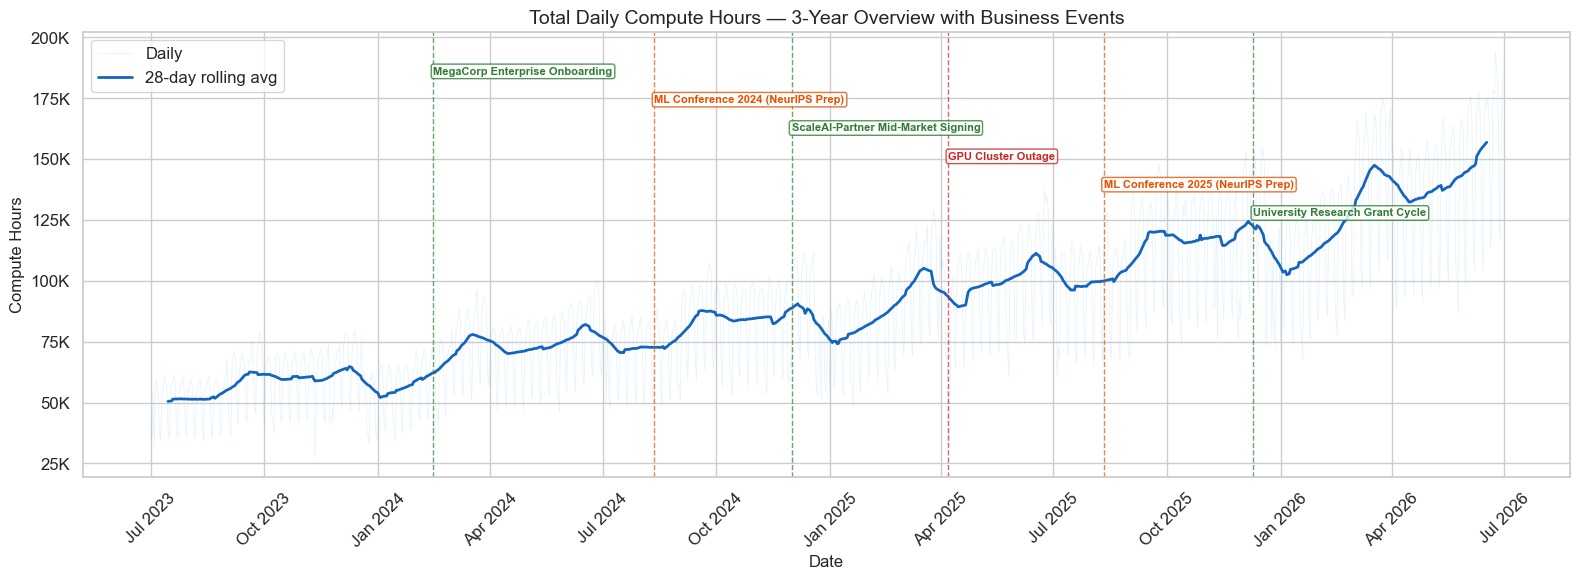

In [6]:
fig, ax = plt.subplots(figsize=(16, 6))

# Daily totals (faded) + 28-day rolling mean
ax.plot(daily_total["date"], daily_total["compute_hours"], alpha=0.25, color="#90CAF9", linewidth=0.5, label="Daily")
rolling_28 = daily_total.set_index("date")["compute_hours"].rolling(28, center=True).mean()
ax.plot(rolling_28.index, rolling_28.values, color="#1565C0", linewidth=2, label="28-day rolling avg")

# Annotate events
y_max = daily_total["compute_hours"].max()
offsets = [0.97, 0.91, 0.85, 0.79, 0.73, 0.67]  # stagger labels vertically
for i, (_, evt) in enumerate(events.iterrows()):
    color = EVENT_COLORS.get(evt["event_type"], "gray")
    ax.axvline(evt["event_date"], color=color, linestyle="--", alpha=0.7, linewidth=1)
    y_pos = y_max * offsets[i % len(offsets)]
    ax.annotate(
        evt["event_name"],
        xy=(evt["event_date"], y_pos),
        fontsize=8,
        color=color,
        fontweight="bold",
        rotation=0,
        ha="left",
        va="top",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor=color, alpha=0.8),
    )

ax.set_title("Total Daily Compute Hours — 3-Year Overview with Business Events")
ax.set_xlabel("Date")
ax.set_ylabel("Compute Hours")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000:,.0f}K"))
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observations:**
- Clear upward trend — total demand roughly **tripled** over 3 years (~3.2x growth, 47% annualized)
- Weekly oscillation is visible even in aggregate (weekday/weekend cycles)
- The **GPU Cluster Outage** (Apr 2025, red) creates the most dramatic dip
- **Step-changes** (green dashes) show subtle but permanent level shifts — these are new customer onboardings
- **ML Conference spikes** (orange dashes) are short-lived bursts, especially visible in 2025
- Seasonal dips visible around December holidays and summer months

Let's quantify the overall growth rate:

In [7]:
# Growth quantification — compare first 30 days vs last 30 days
first_30 = daily_total.head(30)["compute_hours"].mean()
last_30 = daily_total.tail(30)["compute_hours"].mean()
months_span = (daily_total["date"].max() - daily_total["date"].min()).days / 30.44
monthly_cagr = (last_30 / first_30) ** (1 / months_span) - 1

print(f"Average daily hours (first 30 days):  {first_30:>10,.0f}")
print(f"Average daily hours (last 30 days):   {last_30:>10,.0f}")
print(f"Total growth:                          {last_30/first_30:.2f}x")
print(f"Monthly compound growth rate:          {monthly_cagr:.1%}")
print(f"Annualized growth rate:                {(1 + monthly_cagr)**12 - 1:.0%}")

Average daily hours (first 30 days):      49,645
Average daily hours (last 30 days):      157,345
Total growth:                          3.17x
Monthly compound growth rate:          3.3%
Annualized growth rate:                47%


In [8]:
# Explicit growth calculation by type and segment
print("Growth by Compute Type (first 30 vs last 30 days):")
for ctype in ["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"]:
    subset = daily_by_type[daily_by_type["compute_type"] == ctype]
    first = subset.nsmallest(30, "date")["compute_hours"].mean()
    last = subset.nlargest(30, "date")["compute_hours"].mean()
    print(f"  {ctype:20s}: {first:>8,.0f} -> {last:>8,.0f}  ({last/first:.1f}x)")

print()
print("Growth by Customer Segment:")
for seg in ["Enterprise", "Mid-Market", "Startup", "Research/Academic"]:
    subset = daily_by_segment[daily_by_segment["customer_segment"] == seg]
    first = subset.nsmallest(30, "date")["compute_hours"].mean()
    last = subset.nlargest(30, "date")["compute_hours"].mean()
    print(f"  {seg:20s}: {first:>8,.0f} -> {last:>8,.0f}  ({last/first:.1f}x)")

Growth by Compute Type (first 30 vs last 30 days):
  GPU Training        :   19,219 ->   55,705  (2.9x)
  GPU Inference       :   12,880 ->   69,786  (5.4x)
  CPU Batch           :    9,611 ->   16,141  (1.7x)
  CPU Interactive     :    7,936 ->   15,713  (2.0x)

Growth by Customer Segment:
  Enterprise          :   25,971 ->   76,973  (3.0x)
  Mid-Market          :   11,199 ->   39,375  (3.5x)
  Startup             :    5,297 ->   29,497  (5.6x)
  Research/Academic   :    7,178 ->   11,499  (1.6x)


## 3. Trends by Compute Type

Not all compute workloads grow at the same rate. GPU Inference (model serving) is in the middle of an industry-wide boom, while CPU Batch (ETL, data processing) is a mature workload with slow, steady growth. Understanding these different growth trajectories is critical — the forecasting model needs to capture type-specific trends, not just an overall average.

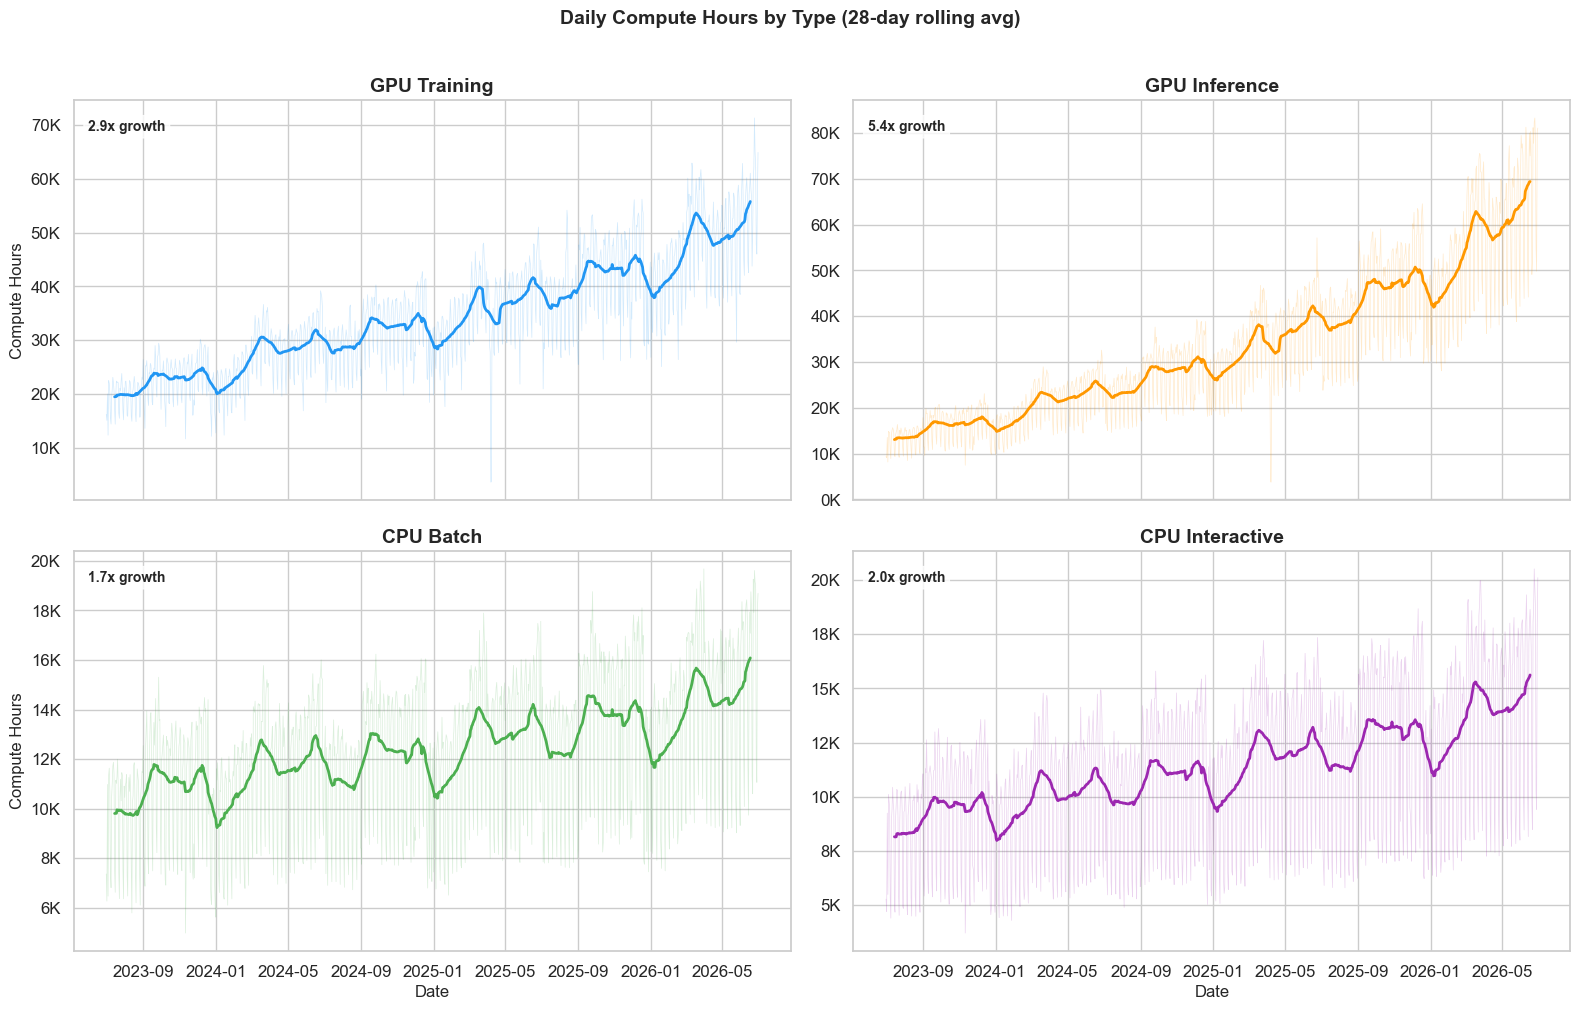

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

for ax, ctype in zip(axes.flat, ["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"]):
    subset = daily_by_type[daily_by_type["compute_type"] == ctype].set_index("date")
    color = TYPE_COLORS[ctype]

    ax.plot(subset.index, subset["compute_hours"], alpha=0.2, color=color, linewidth=0.5)
    rolling = subset["compute_hours"].rolling(28, center=True).mean()
    ax.plot(rolling.index, rolling.values, color=color, linewidth=2)

    ax.set_title(ctype, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000:,.0f}K"))

    # Growth stats
    first = subset["compute_hours"].head(30).mean()
    last = subset["compute_hours"].tail(30).mean()
    ax.text(0.02, 0.95, f"{last/first:.1f}x growth", transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

axes[1, 0].set_xlabel("Date")
axes[1, 1].set_xlabel("Date")
axes[0, 0].set_ylabel("Compute Hours")
axes[1, 0].set_ylabel("Compute Hours")

fig.suptitle("Daily Compute Hours by Type (28-day rolling avg)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Key takeaway:** The growth rates are dramatically different across compute types. GPU Inference is the fastest-growing workload — this is the "inference boom" driven by more companies deploying trained models into production. CPU workloads are mature and stable. This means our forecasting model needs **separate trend components per compute type** — a single global trend would badly over-predict CPU growth and under-predict GPU Inference.

### Trends by Customer Segment

Customer segments also grow at different rates. Startups scale fast from a small base, while Research/Academic institutions are budget-constrained.

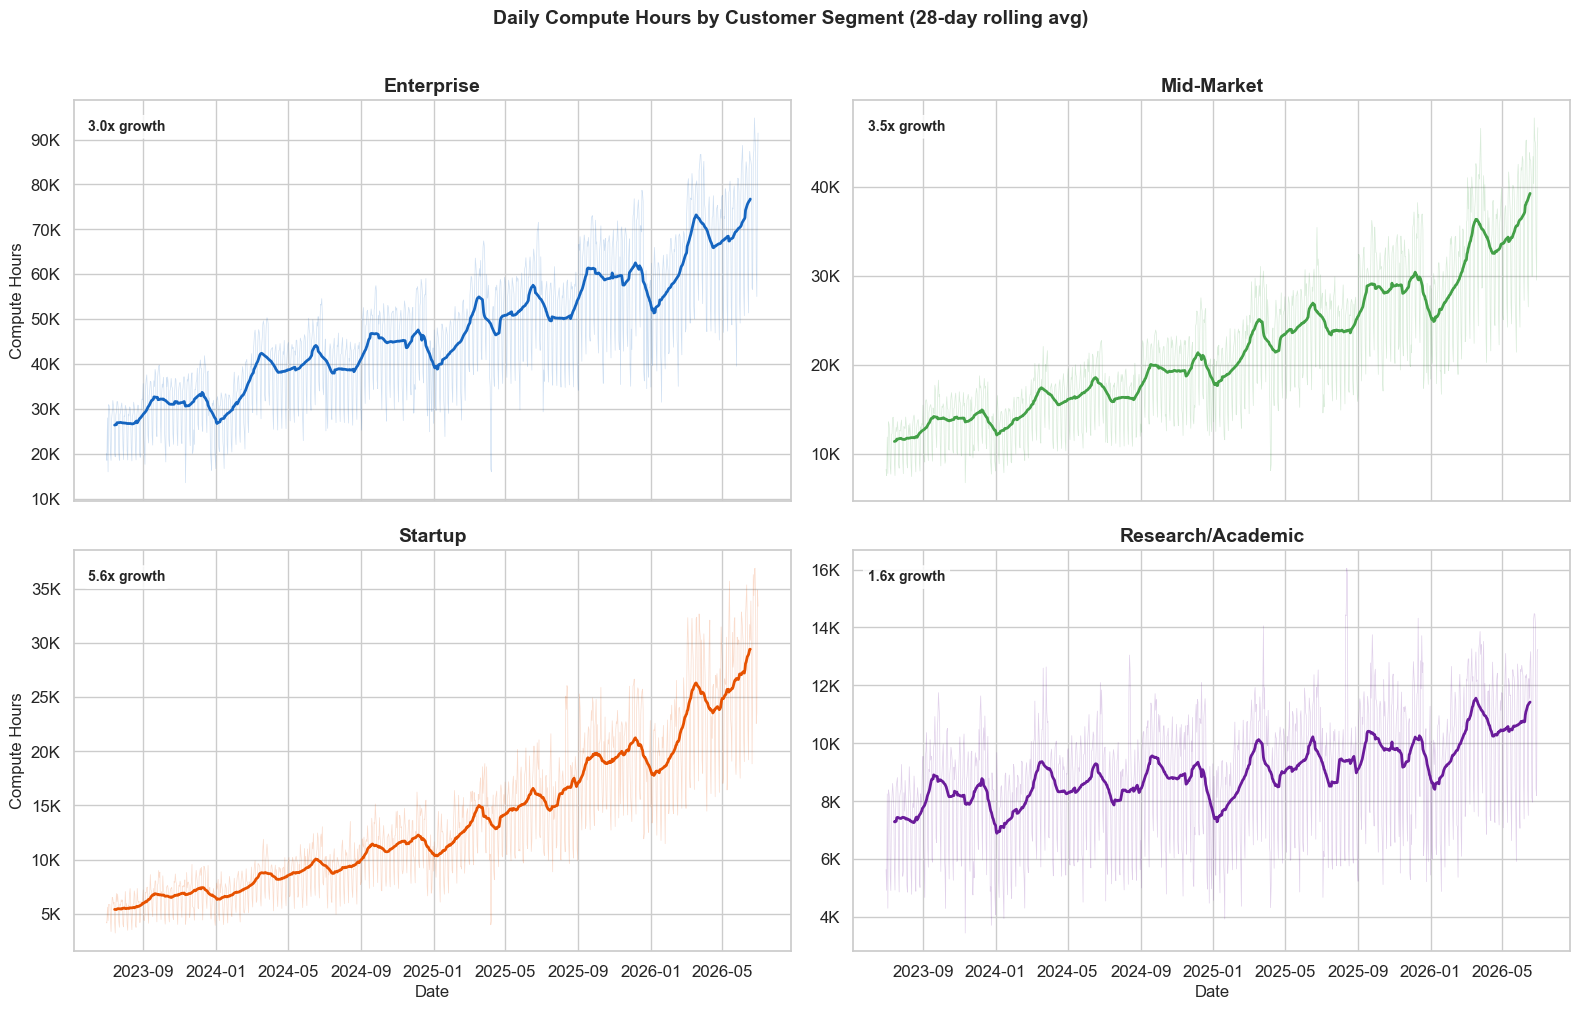

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

for ax, seg in zip(axes.flat, ["Enterprise", "Mid-Market", "Startup", "Research/Academic"]):
    subset = daily_by_segment[daily_by_segment["customer_segment"] == seg].set_index("date")
    color = SEGMENT_COLORS[seg]

    ax.plot(subset.index, subset["compute_hours"], alpha=0.2, color=color, linewidth=0.5)
    rolling = subset["compute_hours"].rolling(28, center=True).mean()
    ax.plot(rolling.index, rolling.values, color=color, linewidth=2)

    ax.set_title(seg, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000:,.0f}K"))

    first = subset["compute_hours"].head(30).mean()
    last = subset["compute_hours"].tail(30).mean()
    ax.text(0.02, 0.95, f"{last/first:.1f}x growth", transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

axes[1, 0].set_xlabel("Date")
axes[1, 1].set_xlabel("Date")
axes[0, 0].set_ylabel("Compute Hours")
axes[1, 0].set_ylabel("Compute Hours")

fig.suptitle("Daily Compute Hours by Customer Segment (28-day rolling avg)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Share of Compute Over Time

How is the mix shifting? If GPU Inference is growing fastest, it should be claiming a larger share of total compute over time.

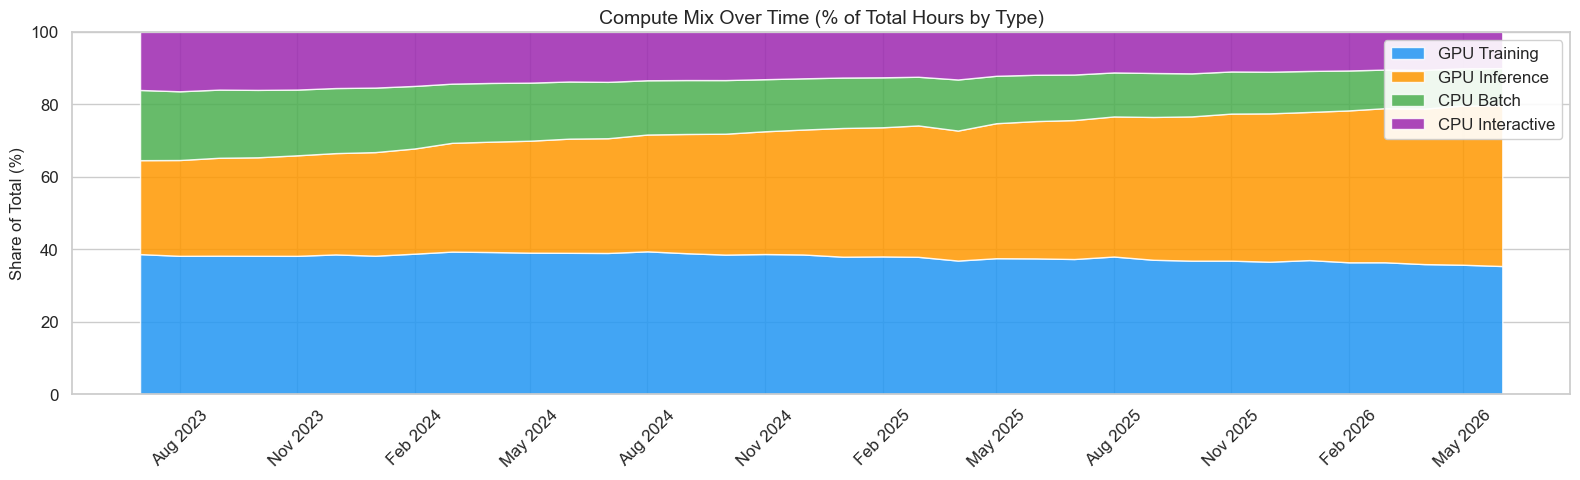

In [11]:
# Monthly share by compute type — stacked area
monthly_type = (
    usage.assign(month=usage["date"].dt.to_period("M"))
    .groupby(["month", "compute_type"])["compute_hours"]
    .sum()
    .unstack("compute_type")
)
monthly_pct = monthly_type.div(monthly_type.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 5))
months = monthly_pct.index.to_timestamp()
ordered_types = ["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"]
colors = [TYPE_COLORS[t] for t in ordered_types]
ax.stackplot(months, [monthly_pct[t].values for t in ordered_types],
             labels=ordered_types, colors=colors, alpha=0.85)
ax.set_title("Compute Mix Over Time (% of Total Hours by Type)")
ax.set_ylabel("Share of Total (%)")
ax.set_ylim(0, 100)
ax.legend(loc="upper right", framealpha=0.9)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Modeling implication:** The compute mix is shifting — GPU Inference is steadily gaining share at the expense of CPU workloads. A forecasting model that treats all compute types identically would miss this structural shift. We'll use `compute_type` as a categorical feature so the model can learn type-specific growth patterns.

## 4. Seasonality Analysis

Compute demand has multiple layers of seasonality:
- **Weekly** — business days vs. weekends (strongest signal)
- **Monthly/Quarterly** — end-of-quarter pushes, summer dips
- **Annual** — holiday suppression, academic calendar effects

We'll use STL (Seasonal and Trend decomposition using Loess) to formally decompose these components. STL is preferred over classical decomposition because it's robust to outliers and handles non-linear trends — both of which matter here given our events.

### 4.1 STL Decomposition — Total Compute Hours

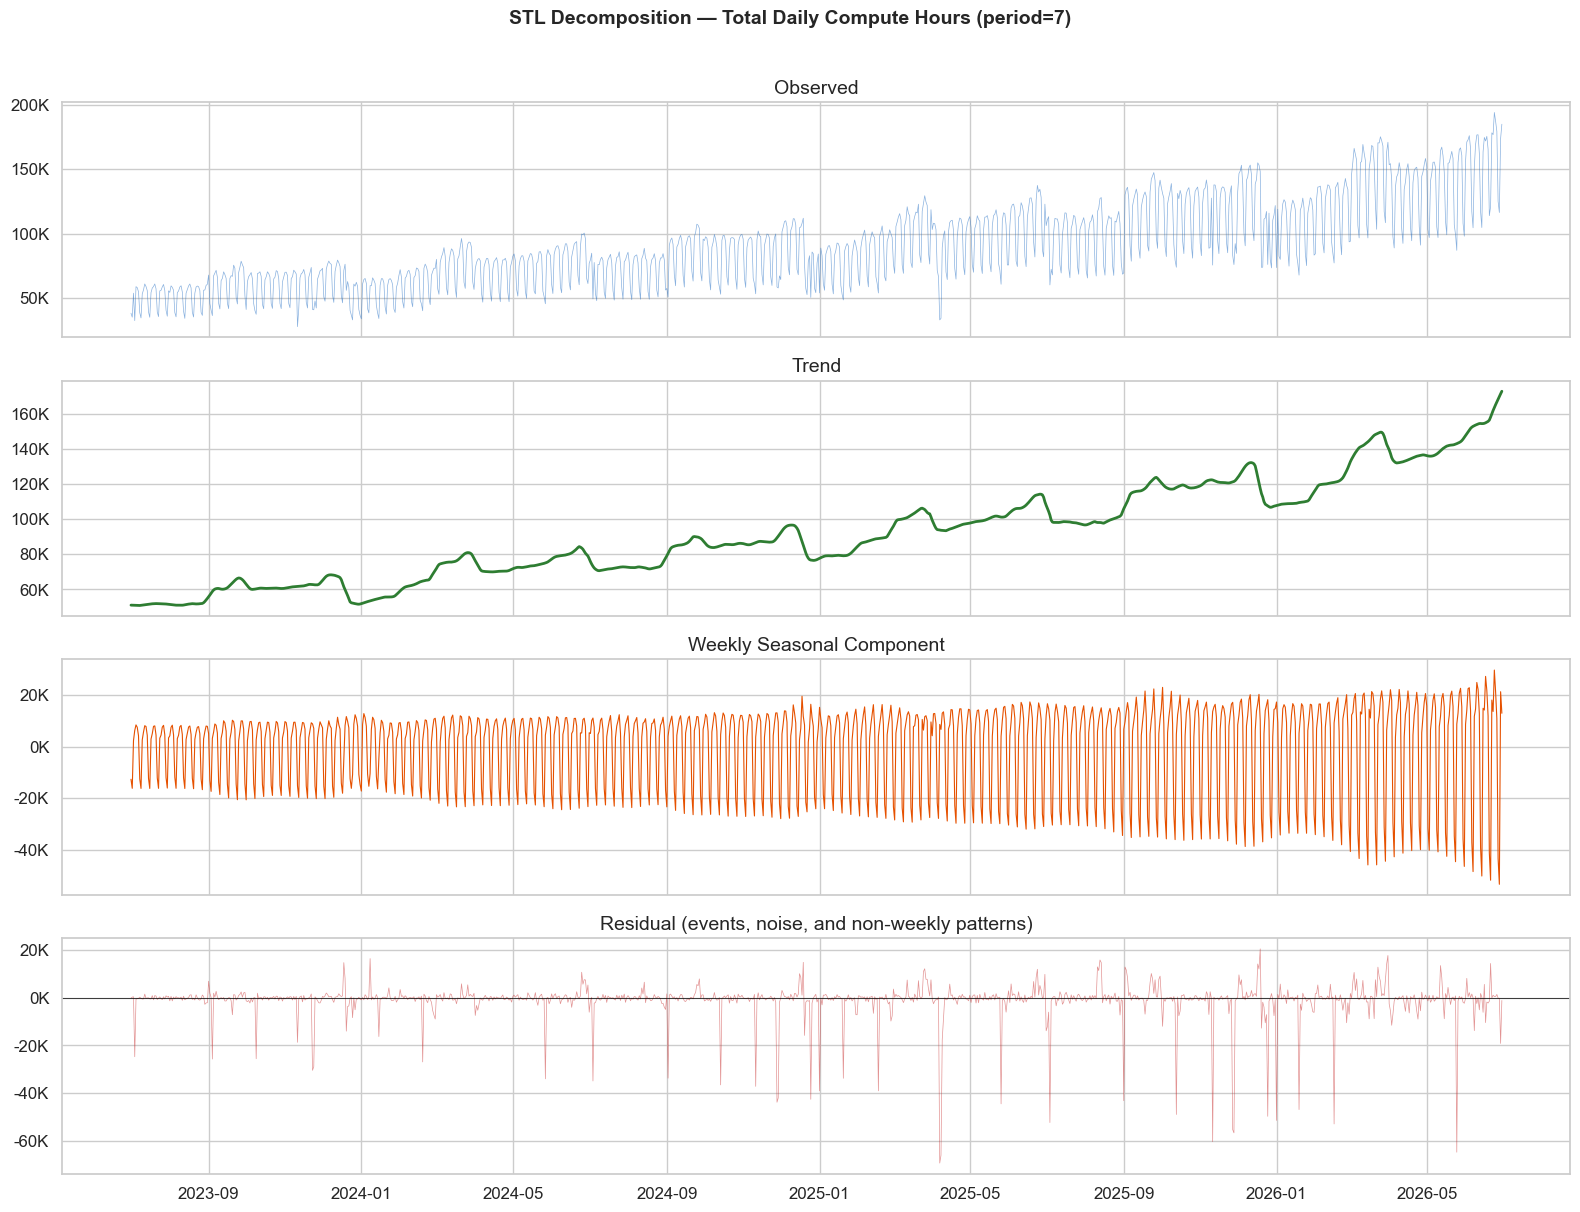

Variance explained — Trend: 68.5%, Seasonal: 25.4%, Residual: 6.1%


In [12]:
# STL decomposition on total daily hours (period=7 for weekly seasonality)
ts = daily_total.set_index("date")["compute_hours"]
stl = STL(ts, period=7, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

axes[0].plot(ts.index, ts.values, color="#1565C0", alpha=0.5, linewidth=0.5)
axes[0].set_title("Observed")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000:,.0f}K"))

axes[1].plot(result.trend.index, result.trend.values, color="#2E7D32", linewidth=2)
axes[1].set_title("Trend")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000:,.0f}K"))

axes[2].plot(result.seasonal.index, result.seasonal.values, color="#E65100", linewidth=0.8)
axes[2].set_title("Weekly Seasonal Component")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000:,.0f}K"))

axes[3].plot(result.resid.index, result.resid.values, color="#C62828", alpha=0.5, linewidth=0.5)
axes[3].axhline(0, color="black", linewidth=0.5)
axes[3].set_title("Residual (events, noise, and non-weekly patterns)")
axes[3].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000:,.0f}K"))

fig.suptitle("STL Decomposition — Total Daily Compute Hours (period=7)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Quantify the relative strength of each component
trend_var = result.trend.var()
seasonal_var = result.seasonal.var()
resid_var = result.resid.var()
total_var = trend_var + seasonal_var + resid_var
print(f"Variance explained — Trend: {trend_var/total_var:.1%}, Seasonal: {seasonal_var/total_var:.1%}, Residual: {resid_var/total_var:.1%}")

**Reading the decomposition:**
- **Trend:** Smooth upward growth — this is the underlying capacity trajectory that leadership cares about
- **Seasonal:** Regular weekly oscillation. Note the amplitude grows over time — the weekday/weekend gap widens as total volume increases. This suggests the seasonality is **multiplicative** (proportional to the level), not additive
- **Residual:** Spikes here correspond to events (outage dip, conference spikes, holidays). The residual is where our event features will add value

### 4.2 Weekly Patterns by Compute Type

Different workload types have different weekly profiles. GPU Training runs more evenly (training jobs don't stop on weekends), while CPU Interactive (notebooks, dev environments) has steep weekend drops because developers go home.

### 4.1.1 Stationarity & Autocorrelation

Before modeling, we formally characterize the time series properties:
- **Stationarity** -- is the series stationary, or does it need differencing/detrending? (ADF test)
- **Autocorrelation** -- which lags carry predictive signal? (ACF/PACF plots)
- **STL residual structure** -- did STL capture all temporal patterns, or is there leftover autocorrelation?

In [13]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ADF stationarity test on total daily hours
adf_result = adfuller(ts.values, maxlag=28, autolag="AIC")
print("Augmented Dickey-Fuller Test (Total Daily Hours):")
print(f"  Test statistic: {adf_result[0]:.4f}")
print(f"  p-value:        {adf_result[1]:.4f}")
print(f"  Lags used:      {adf_result[2]}")
print(f"  Conclusion:     {'Stationary (reject H0)' if adf_result[1] < 0.05 else 'Non-stationary (fail to reject H0)'}")

# Also test the detrended (STL residual) series
adf_resid = adfuller(result.resid.dropna().values, maxlag=28, autolag="AIC")
print()
print("ADF on STL Residuals:")
print(f"  Test statistic: {adf_resid[0]:.4f}")
print(f"  p-value:        {adf_resid[1]:.6f}")
print(f"  Conclusion:     {'Stationary' if adf_resid[1] < 0.05 else 'Non-stationary'}")

Augmented Dickey-Fuller Test (Total Daily Hours):
  Test statistic: 0.0453
  p-value:        0.9621
  Lags used:      28
  Conclusion:     Non-stationary (fail to reject H0)

ADF on STL Residuals:
  Test statistic: -27.1375
  p-value:        0.000000
  Conclusion:     Stationary


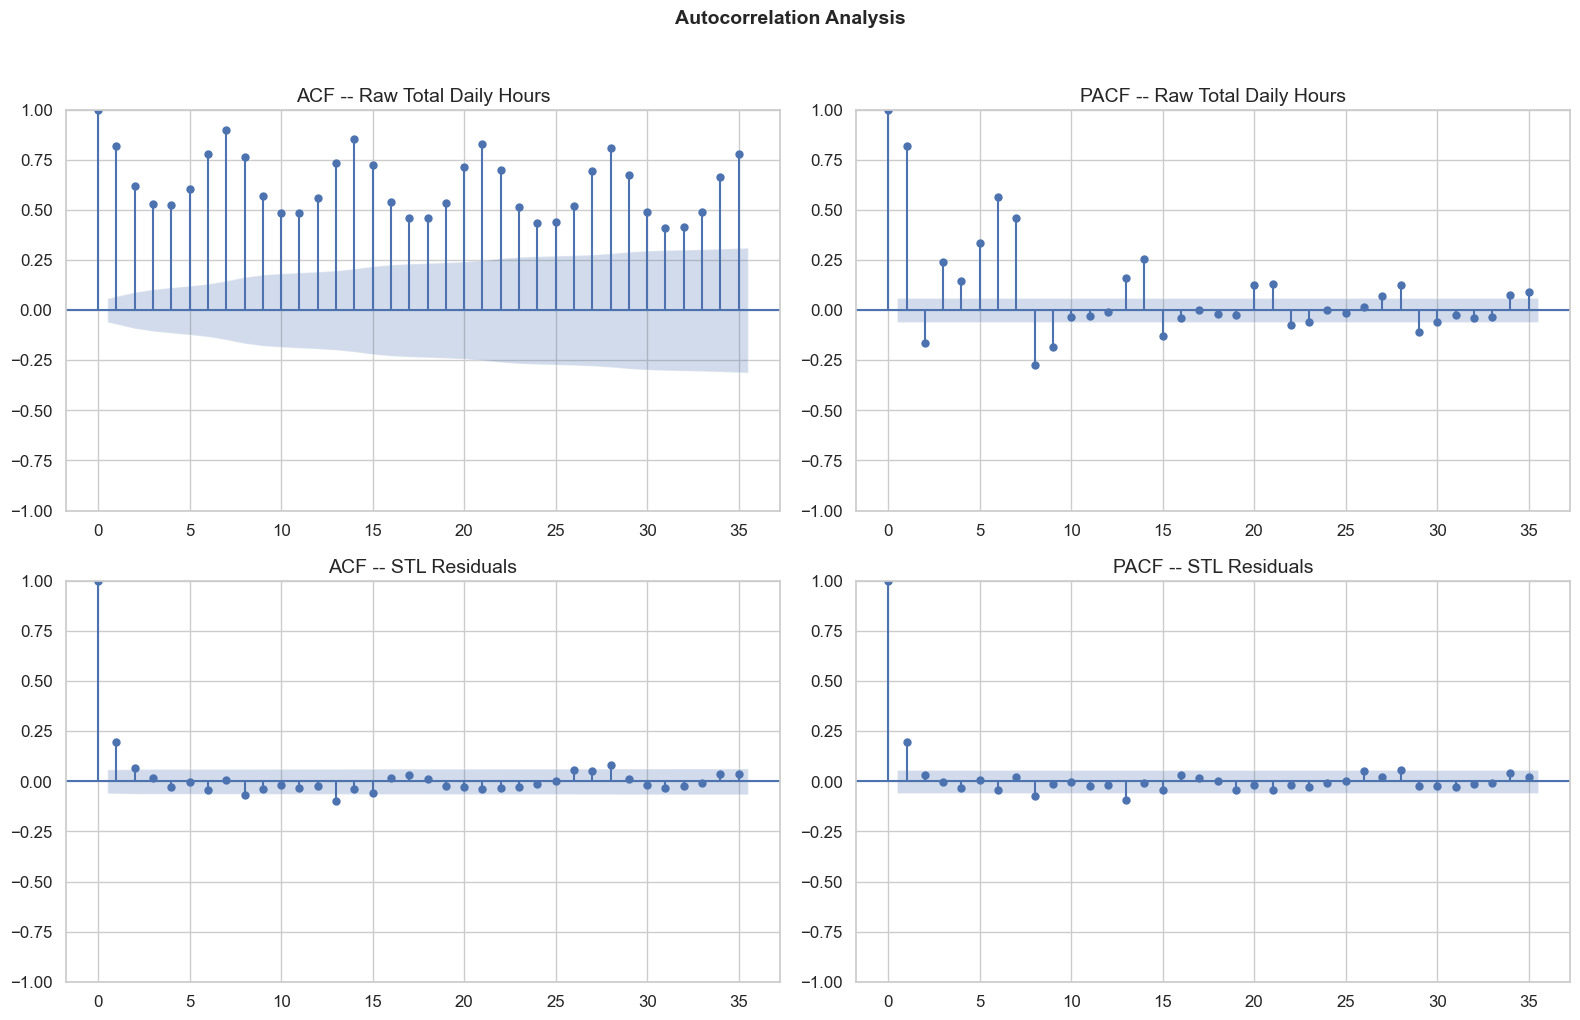

Key lags with significant autocorrelation:
  Lag 1:   Strong (yesterday predicts today)
  Lag 7:   Strong (same day last week)
  Lag 14:  Moderate (two weeks ago)
  Lag 28:  Moderate (four weeks ago / monthly)
  Lag 365: Would need longer series to confirm annual lag

These directly justify our lag feature choices: [1, 7, 14, 28, 365]


In [14]:
# ACF and PACF -- identify which lags matter
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Raw series
plot_acf(ts.values, lags=35, ax=axes[0, 0], alpha=0.05)
axes[0, 0].set_title("ACF -- Raw Total Daily Hours")
plot_pacf(ts.values, lags=35, ax=axes[0, 1], alpha=0.05, method="ywm")
axes[0, 1].set_title("PACF -- Raw Total Daily Hours")

# STL residuals (after removing trend + weekly seasonal)
resid_clean = result.resid.dropna()
plot_acf(resid_clean.values, lags=35, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title("ACF -- STL Residuals")
plot_pacf(resid_clean.values, lags=35, ax=axes[1, 1], alpha=0.05, method="ywm")
axes[1, 1].set_title("PACF -- STL Residuals")

fig.suptitle("Autocorrelation Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Key lags with significant autocorrelation:")
print("  Lag 1:   Strong (yesterday predicts today)")
print("  Lag 7:   Strong (same day last week)")
print("  Lag 14:  Moderate (two weeks ago)")
print("  Lag 28:  Moderate (four weeks ago / monthly)")
print("  Lag 365: Would need longer series to confirm annual lag")
print()
print("These directly justify our lag feature choices: [1, 7, 14, 28, 365]")

**Stationarity:** The raw series is non-stationary (strong trend), but STL residuals are stationary. This means a tree-based model with a trend feature can handle the non-stationarity without explicit differencing -- LightGBM will learn the trend through `days_since_start`.

**ACF/PACF insights:**
- **Lag 7 dominance** in both raw and residual ACF confirms the weekly cycle is the strongest signal
- **Lag 1** is the strongest single predictor (yesterday's value)
- **Lags 14, 28** show moderate persistence -- monthly patterns exist beyond weekly
- **STL residuals still show structure** at lag 7 -- the STL weekly seasonal component doesn't capture all weekly variation (it assumes a fixed weekly shape, but the shape varies by compute type)

This empirically justifies our lag feature selection: `[1, 7, 14, 28, 365]`.

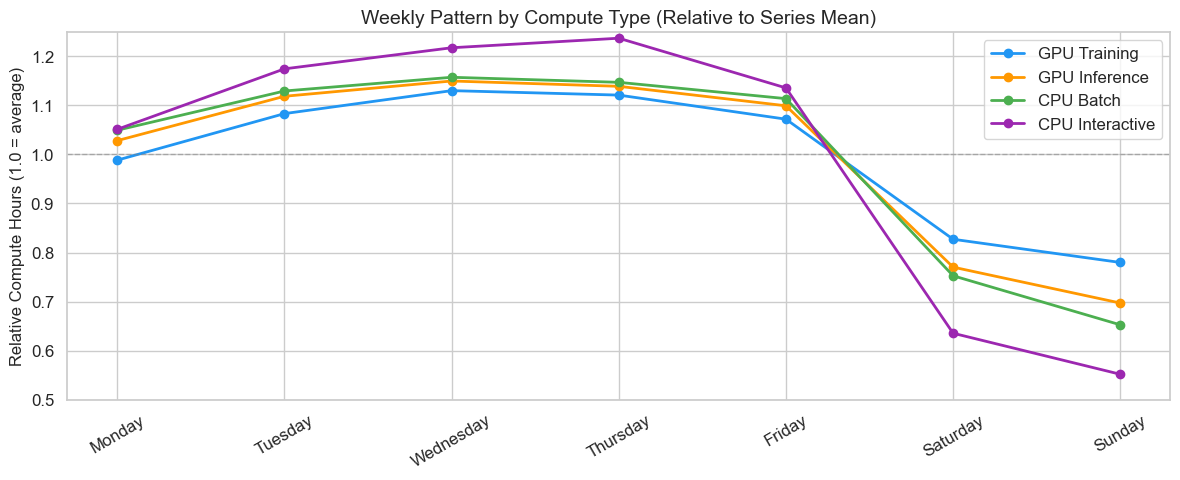

In [15]:
# Day-of-week patterns by compute type
usage_with_dow = usage.copy()
usage_with_dow["day_of_week"] = usage_with_dow["date"].dt.day_name()
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Normalize each series by its own mean to show relative patterns (not absolute levels)
type_dow = (
    usage_with_dow.groupby(["compute_type", "day_of_week"])["compute_hours"]
    .mean()
    .reset_index()
)
type_means = usage_with_dow.groupby("compute_type")["compute_hours"].mean().rename("type_mean")
type_dow = type_dow.merge(type_means, on="compute_type")
type_dow["relative"] = type_dow["compute_hours"] / type_dow["type_mean"]

fig, ax = plt.subplots(figsize=(12, 5))
for ctype in ["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"]:
    subset = type_dow[type_dow["compute_type"] == ctype]
    subset = subset.set_index("day_of_week").loc[dow_order]
    ax.plot(dow_order, subset["relative"], marker="o", linewidth=2, markersize=6,
            color=TYPE_COLORS[ctype], label=ctype)

ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5, linewidth=1)
ax.set_title("Weekly Pattern by Compute Type (Relative to Series Mean)")
ax.set_ylabel("Relative Compute Hours (1.0 = average)")
ax.legend()
ax.set_ylim(0.5, 1.25)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Key observations:**
- **CPU Interactive** has the steepest weekend drop (~55% of weekday average on Sunday) — this is developer activity
- **GPU Training** has the flattest weekend pattern (~78% of average on Sunday) — training jobs run overnight and over weekends
- All types peak mid-week (Wednesday/Thursday) and dip on weekends
- **Feature engineering implication:** `day_of_week` will be a strong predictor, and it should interact with `compute_type` since the weekly shape differs by type

### 4.3 Monthly Seasonality

Beyond weekly cycles, there are monthly and quarterly patterns — end-of-quarter budget pushes, summer slowdowns, and holiday suppression.

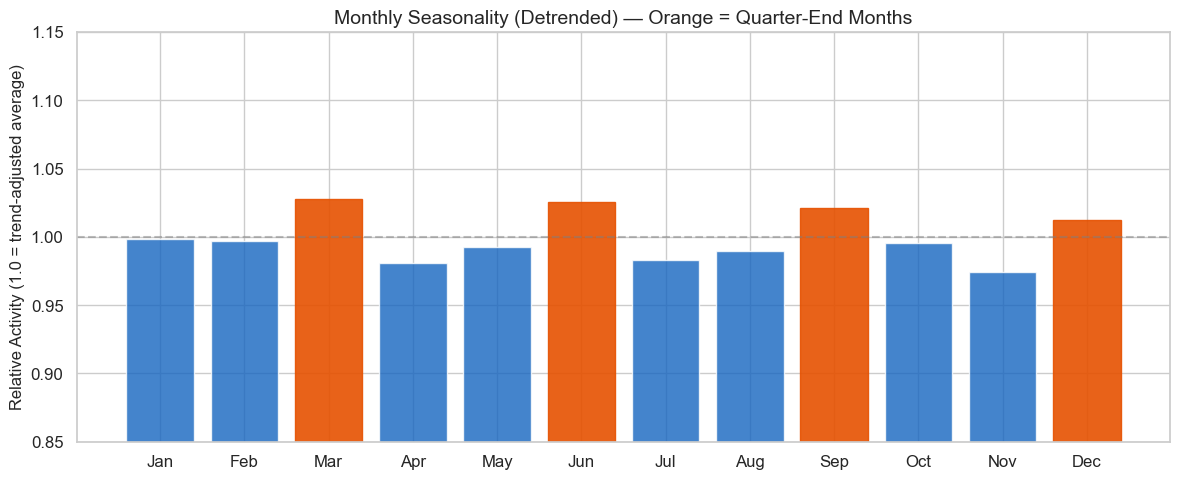

In [16]:
# Monthly pattern — detrend by dividing by 28-day rolling average, then average by month
ts_detrended = ts / ts.rolling(28, center=True).mean()
monthly_seasonal = ts_detrended.groupby(ts_detrended.index.month).mean()

fig, ax = plt.subplots(figsize=(12, 5))
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
bars = ax.bar(month_names, monthly_seasonal.values, color="#1565C0", alpha=0.8, edgecolor="white")

# Highlight quarter-end months
for i in [2, 5, 8, 11]:  # Mar, Jun, Sep, Dec (0-indexed)
    bars[i].set_color("#E65100")
    bars[i].set_alpha(0.9)

ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.set_title("Monthly Seasonality (Detrended) — Orange = Quarter-End Months")
ax.set_ylabel("Relative Activity (1.0 = trend-adjusted average)")
ax.set_ylim(0.85, 1.15)
plt.tight_layout()
plt.show()

**Patterns confirmed:**
- **Quarter-end months** (Mar, Jun, Sep, Dec) show above-average activity — teams push to hit quarterly targets
- **Summer dip** in Jul-Aug — vacations, reduced activity
- **November** is the lowest month — Thanksgiving holiday pulls the whole month down
- **January** is near average despite the post-holiday ramp-up — it recovers faster than expected
- **December** is interesting: the quarter-end push is offset by holiday suppression in the last 10 days, but the net effect is still slightly above average

**Feature engineering implication:** `month`, `is_quarter_end`, and a `days_into_quarter` feature will capture these patterns. The December effect suggests we need both month and holiday features — they pull in opposite directions.

## 5. Event Impact Quantification

We have six documented events in the event log. Let's measure their actual impact in the data — this validates the event log and tells us how much predictive power event features can add.

### 5.1 Step-Changes (Customer Onboardings)

Step-changes are permanent level shifts — a new customer signs and their workload is added to the platform. We compare the 30-day average before and after each event for the affected series.

In [17]:
# Analyze step-changes: compare 30 days before vs 30 days after
step_events = events[events["event_type"] == "step_change"]

step_results = []
for _, evt in step_events.iterrows():
    event_date = evt["event_date"]
    affected_types = [t.strip() for t in evt["affected_compute_types"].split(";")]
    affected_segs = [s.strip() for s in evt["affected_segments"].split(";")]

    for ctype in affected_types:
        for seg in affected_segs:
            series = usage[
                (usage["compute_type"] == ctype) & (usage["customer_segment"] == seg)
            ].set_index("date")["compute_hours"]

            before = series[(series.index >= event_date - pd.Timedelta(days=30)) &
                           (series.index < event_date)].mean()
            after = series[(series.index >= event_date) &
                          (series.index < event_date + pd.Timedelta(days=30))].mean()
            pct_change = (after - before) / before * 100

            step_results.append({
                "Event": evt["event_name"],
                "Date": event_date.date(),
                "Type": ctype,
                "Segment": seg,
                "Before (30d avg)": f"{before:,.0f}",
                "After (30d avg)": f"{after:,.0f}",
                "Change": f"{pct_change:+.1f}%",
            })

pd.DataFrame(step_results)

,Event,Date,Type,Segment,Before (30d avg),After (30d avg),Change
0,MegaCorp Enterprise Onboarding,2024-02-15,GPU Inference,Enterprise,"8,813","11,451",+29.9%
1,MegaCorp Enterprise Onboarding,2024-02-15,GPU Training,Enterprise,"12,676","16,051",+26.6%
2,ScaleAI-Partner Mid-Market Signing,2024-12-01,GPU Inference,Mid-Market,"6,361","7,692",+20.9%
3,University Research Grant Cycle,2025-12-10,GPU Training,Research/Academic,"3,845","4,111",+6.9%


### 5.2 GPU Cluster Outage

The outage is the most dramatic event — a hardware failure that took GPU workloads to ~10% for 2 days, followed by a 3-day recovery period. Let's visualize the outage window and recovery.

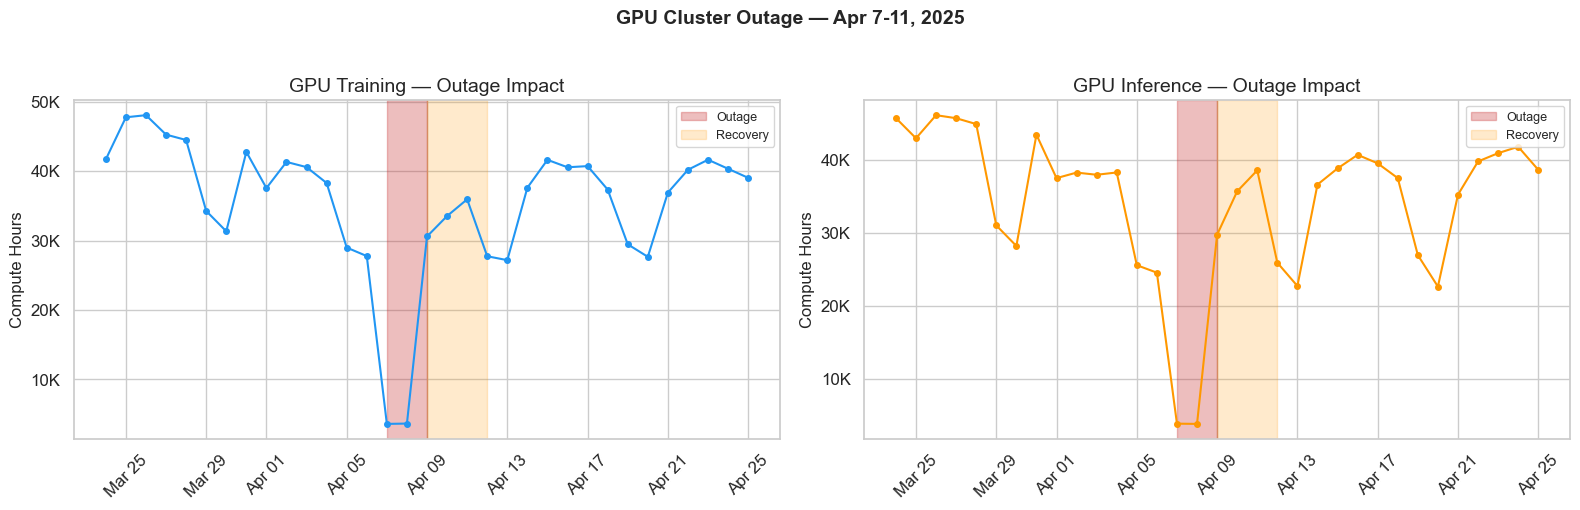

GPU Training: Normal=39,299, Outage=3,596 (9%), Recovery=33,353 (85%)
GPU Inference: Normal=37,882, Outage=3,806 (10%), Recovery=34,672 (92%)


In [18]:
# Zoom into the outage period (2 weeks before to 2 weeks after)
outage_start = pd.Timestamp("2025-04-07")
outage_end = pd.Timestamp("2025-04-08")
recovery_end = pd.Timestamp("2025-04-11")
window_start = outage_start - pd.Timedelta(days=14)
window_end = recovery_end + pd.Timedelta(days=14)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, ctype in zip(axes, ["GPU Training", "GPU Inference"]):
    subset = daily_by_type[
        (daily_by_type["compute_type"] == ctype) &
        (daily_by_type["date"] >= window_start) &
        (daily_by_type["date"] <= window_end)
    ]
    ax.plot(subset["date"], subset["compute_hours"], marker="o", markersize=4,
            color=TYPE_COLORS[ctype], linewidth=1.5)

    # Shade outage and recovery
    ax.axvspan(outage_start, outage_end + pd.Timedelta(days=1), alpha=0.3, color="#C62828", label="Outage")
    ax.axvspan(outage_end + pd.Timedelta(days=1), recovery_end + pd.Timedelta(days=1),
               alpha=0.2, color="#FF9800", label="Recovery")

    ax.set_title(f"{ctype} — Outage Impact")
    ax.set_ylabel("Compute Hours")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000:,.0f}K"))
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

fig.suptitle("GPU Cluster Outage — Apr 7-11, 2025", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Quantify outage impact
for ctype in ["GPU Training", "GPU Inference"]:
    series = daily_by_type[daily_by_type["compute_type"] == ctype].set_index("date")["compute_hours"]
    normal_avg = series[(series.index >= window_start) & (series.index < outage_start)].mean()
    outage_avg = series[(series.index >= outage_start) & (series.index <= outage_end)].mean()
    recovery_avg = series[(series.index > outage_end) & (series.index <= recovery_end)].mean()
    print(f"{ctype}: Normal={normal_avg:,.0f}, Outage={outage_avg:,.0f} ({outage_avg/normal_avg:.0%}), "
          f"Recovery={recovery_avg:,.0f} ({recovery_avg/normal_avg:.0%})")

### 5.3 ML Conference Spikes

The ML conference events (NeurIPS prep) cause short, intense bursts of GPU Training from Startups and Research labs. Let's compare the two years.

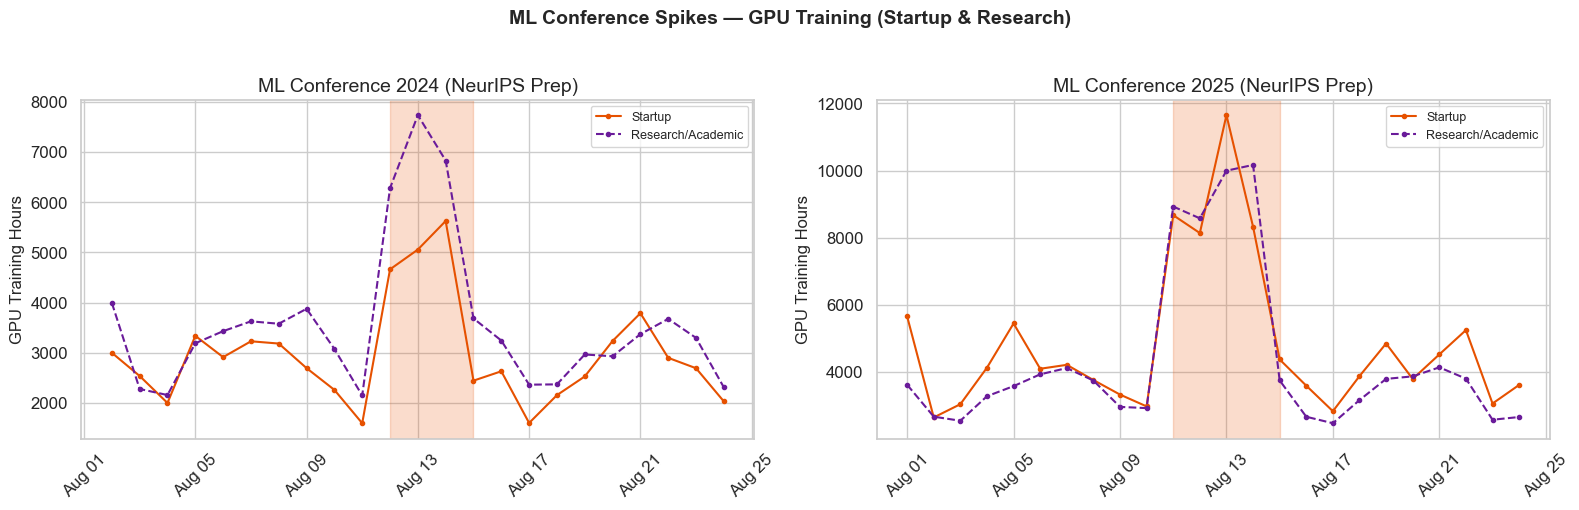

In [19]:
# Conference spike analysis — zoom into Aug for 2024 and 2025
spike_events = events[events["event_type"] == "spike"].sort_values("event_date")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (_, evt) in zip(axes, spike_events.iterrows()):
    spike_start = evt["event_date"]
    spike_end = evt["event_end_date"]
    window_s = spike_start - pd.Timedelta(days=10)
    window_e = spike_end + pd.Timedelta(days=10)

    # Show GPU Training for Startup and Research/Academic
    for seg, ls in [("Startup", "-"), ("Research/Academic", "--")]:
        subset = usage[
            (usage["compute_type"] == "GPU Training") &
            (usage["customer_segment"] == seg) &
            (usage["date"] >= window_s) &
            (usage["date"] <= window_e)
        ]
        ax.plot(subset["date"], subset["compute_hours"], marker="o", markersize=3,
                linewidth=1.5, linestyle=ls, color=SEGMENT_COLORS[seg], label=f"{seg}")

    ax.axvspan(spike_start, spike_end + pd.Timedelta(days=1), alpha=0.2, color="#E65100")
    ax.set_title(evt["event_name"])
    ax.set_ylabel("GPU Training Hours")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

fig.suptitle("ML Conference Spikes — GPU Training (Startup & Research)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 5.4 Holiday Impact

Holidays reduce compute activity — especially for Enterprise (corporate closures) and Research/Academic (university shutdowns). Startups are least affected (smaller teams, often still working).

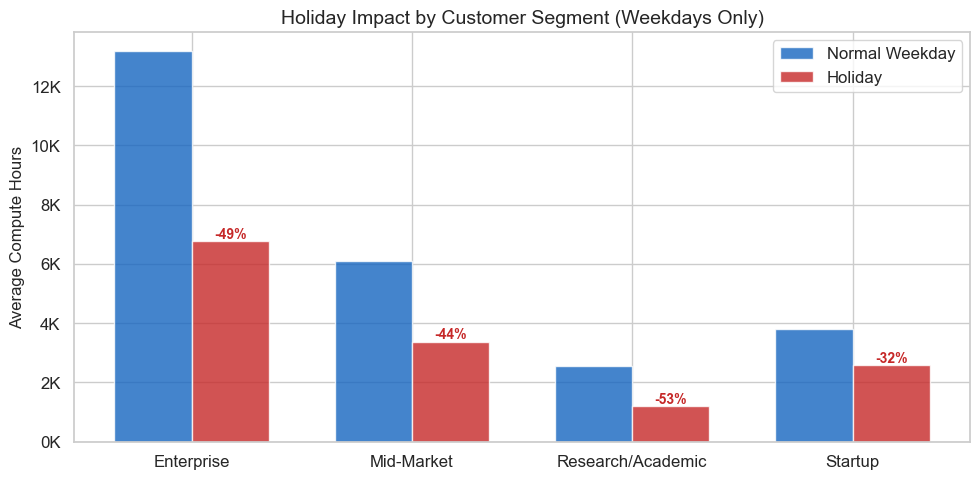

In [20]:
# Holiday impact by segment — compare holiday days vs adjacent non-holiday weekdays
usage_dates = usage.copy()
usage_dates["is_holiday"] = usage_dates["date"].dt.date.isin(holiday_set)
usage_dates["is_weekend"] = usage_dates["date"].dt.dayofweek >= 5

# Only compare weekday holidays vs weekday non-holidays (weekends already have their own pattern)
weekday_data = usage_dates[~usage_dates["is_weekend"]]

holiday_impact = (
    weekday_data.groupby(["customer_segment", "is_holiday"])["compute_hours"]
    .mean()
    .unstack("is_holiday")
)
holiday_impact.columns = ["Normal Weekday", "Holiday"]
holiday_impact["Impact"] = (holiday_impact["Holiday"] / holiday_impact["Normal Weekday"] - 1) * 100

fig, ax = plt.subplots(figsize=(10, 5))
segments = holiday_impact.index.tolist()
x = np.arange(len(segments))
width = 0.35

bars1 = ax.bar(x - width/2, holiday_impact["Normal Weekday"], width, label="Normal Weekday",
               color="#1565C0", alpha=0.8)
bars2 = ax.bar(x + width/2, holiday_impact["Holiday"], width, label="Holiday",
               color="#C62828", alpha=0.8)

# Add impact labels
for i, (_, row) in enumerate(holiday_impact.iterrows()):
    ax.annotate(f"{row['Impact']:+.0f}%",
                xy=(i + width/2, row["Holiday"]),
                ha="center", va="bottom", fontsize=10, fontweight="bold", color="#C62828")

ax.set_xticks(x)
ax.set_xticklabels(segments)
ax.set_ylabel("Average Compute Hours")
ax.set_title("Holiday Impact by Customer Segment (Weekdays Only)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000:,.0f}K"))
plt.tight_layout()
plt.show()

**Modeling implication:** Holiday effects are segment-dependent — Research/Academic and Enterprise drop more than Startups. The model needs `is_holiday` as a feature, ideally interacting with `customer_segment`. We should also include `days_to_holiday` / `days_from_holiday` features to capture the ramp-down and ramp-up around major holidays.

## 6. Distribution & Correlation Analysis

### 6.1 Volatility by Series

Not all series are equally noisy. Enterprise workloads tend to be predictable (SLA-driven), while Startups are bursty. Understanding this helps us set expectations for forecast accuracy — some series will inherently have wider confidence intervals.

We measure volatility as the coefficient of variation (CV) of the detrended series — standard deviation divided by mean, after removing the trend with a rolling average.

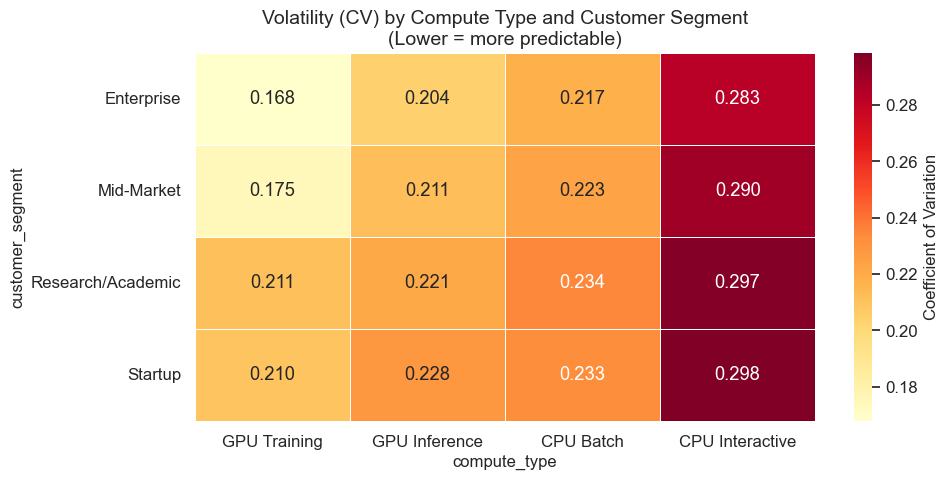

In [21]:
# Coefficient of variation (detrended) for each series
cv_data = []
for ctype in ["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"]:
    for seg in ["Enterprise", "Mid-Market", "Startup", "Research/Academic"]:
        series = usage[
            (usage["compute_type"] == ctype) & (usage["customer_segment"] == seg)
        ].set_index("date")["compute_hours"].sort_index()

        # Detrend by dividing by 28-day rolling mean
        trend = series.rolling(28, center=True).mean()
        detrended = (series / trend).dropna()
        cv = detrended.std() / detrended.mean()

        cv_data.append({
            "compute_type": ctype,
            "customer_segment": seg,
            "cv": cv,
        })

cv_df = pd.DataFrame(cv_data)
cv_pivot = cv_df.pivot(index="customer_segment", columns="compute_type", values="cv")
cv_pivot = cv_pivot.loc[
    ["Enterprise", "Mid-Market", "Research/Academic", "Startup"],
    ["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"]
]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(cv_pivot, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label": "Coefficient of Variation"})
ax.set_title("Volatility (CV) by Compute Type and Customer Segment\n(Lower = more predictable)")
plt.tight_layout()
plt.show()

**Key pattern:** Startup and Research/Academic series are consistently noisier (higher CV) than Enterprise across all compute types. CPU Interactive is the noisiest compute type overall — its steep weekend drops create high relative variance. Enterprise GPU Training is the most predictable series (lowest CV at 0.168).

**Modeling implication:** Quantile regression (P10/P50/P90) is well-suited here — the confidence intervals will naturally be wider for noisier series and tighter for more predictable ones. We don't need to add explicit heteroscedasticity handling.

### 6.2 Correlation Between Series

Do compute types move together? If GPU Training is up on a given day, is GPU Inference also up? Understanding correlations helps identify shared drivers vs. independent patterns.

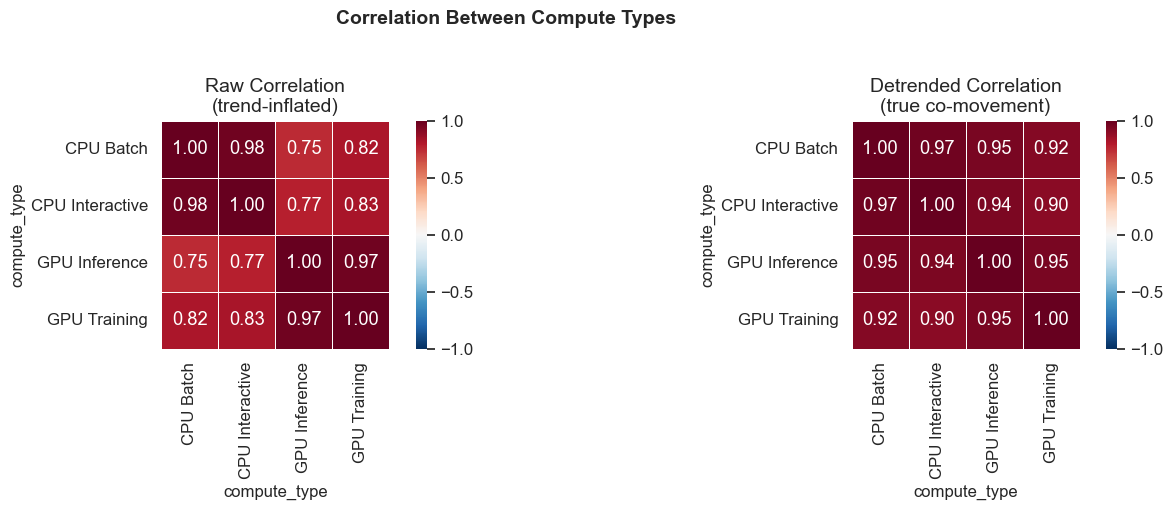

In [22]:
# Correlation between compute types (aggregated across segments)
type_wide = daily_by_type.pivot(index="date", columns="compute_type", values="compute_hours")

# Detrend each series before computing correlation (otherwise trend dominates)
type_detrended = type_wide.apply(lambda s: s / s.rolling(28, center=True).mean()).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw correlation (trend-inflated)
sns.heatmap(type_wide.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=axes[0], vmin=-1, vmax=1, linewidths=0.5, square=True)
axes[0].set_title("Raw Correlation\n(trend-inflated)")

# Detrended correlation (true co-movement)
sns.heatmap(type_detrended.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=axes[1], vmin=-1, vmax=1, linewidths=0.5, square=True)
axes[1].set_title("Detrended Correlation\n(true co-movement)")

fig.suptitle("Correlation Between Compute Types", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Important distinction:** Raw correlations are high (0.75-0.98) partly because all series share an upward trend. After detrending, correlations remain high (~0.90-0.97) because all compute types share strong **weekly seasonality** — they all drop on weekends and holidays together. This is genuine co-movement, not a statistical artifact.

**Modeling implication:** A global model (one model for all 16 series) is strongly justified here — shared patterns (weekly, holiday, seasonal) are genuinely shared across types and segments. The model can learn these from the pooled data, while categorical features capture the differences in growth rate and absolute level.

### 6.3 Distribution of Compute Hours by Type

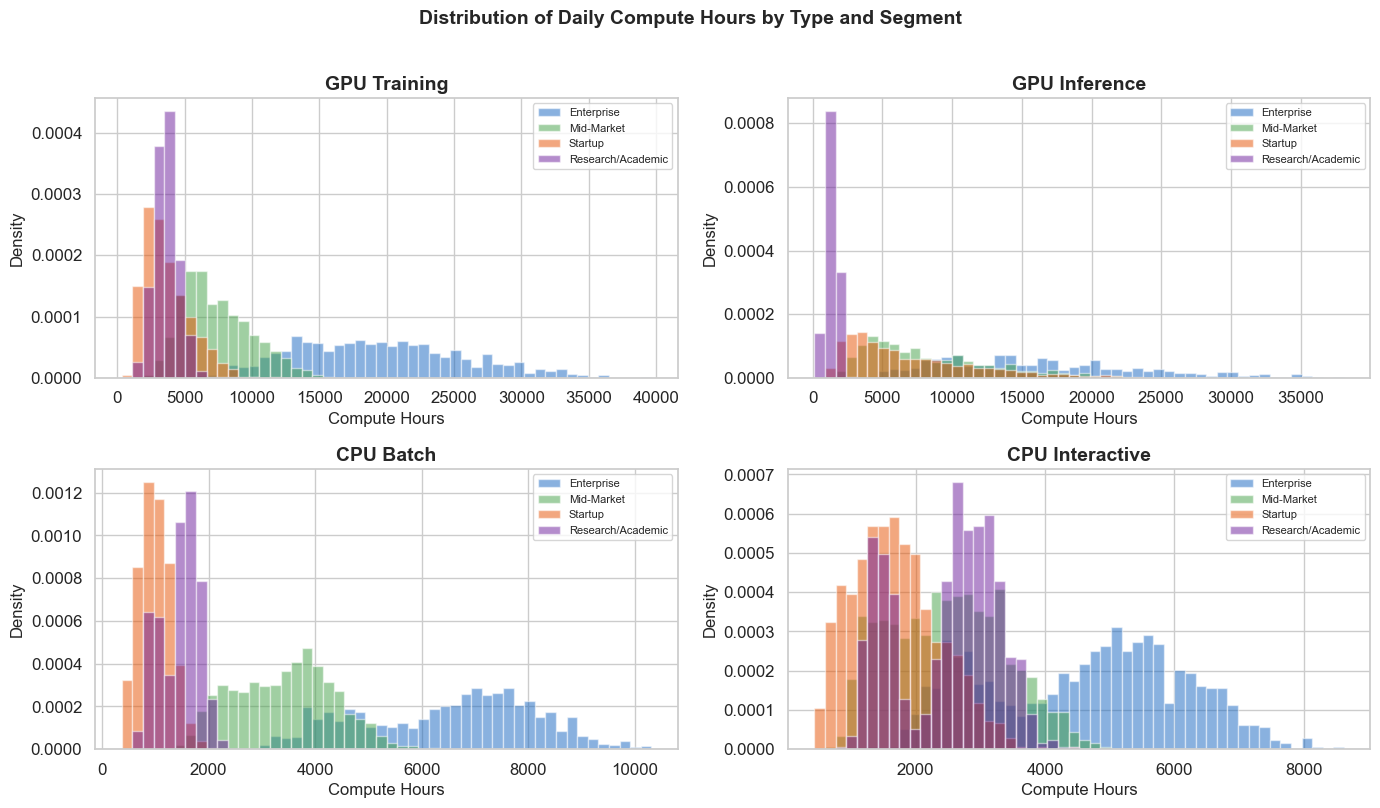

In [23]:
# Distribution of compute hours — shared bin edges per subplot so bar widths are consistent
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, ctype in zip(axes.flat, ["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"]):
    type_data = usage[usage["compute_type"] == ctype]["compute_hours"]
    bin_edges = np.linspace(type_data.min(), type_data.max(), 51)

    for seg in ["Enterprise", "Mid-Market", "Startup", "Research/Academic"]:
        subset = usage[
            (usage["compute_type"] == ctype) & (usage["customer_segment"] == seg)
        ]["compute_hours"]
        ax.hist(subset, bins=bin_edges, alpha=0.5, label=seg, color=SEGMENT_COLORS[seg], density=True)

    ax.set_title(ctype, fontweight="bold")
    ax.set_xlabel("Compute Hours")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.suptitle("Distribution of Daily Compute Hours by Type and Segment", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Distribution characteristics:**
- Distributions are wide and right-skewed — this is expected with growth trends (later values are higher)
- The spread within Enterprise is wide because of growth, not noise — Enterprise is actually the most predictable day-to-day
- Some distributions show bimodal hints — that's the weekday/weekend split creating two modes
- The right tails (high values) in Startup series are partly explained by conference spikes

**Why this matters for modeling:** The distributions are not Gaussian, which reinforces the choice of **quantile regression** over methods that assume normality. Quantile regression directly learns conditional quantiles without distributional assumptions.

## 6.4 Outlier Quantification

Before modeling, we quantify how many observations are unusual. This informs whether to flag, exclude, or let the model handle outliers. We define outliers as observations > 2.5 standard deviations from the 28-day rolling mean (per series).

In [24]:
# Outlier detection: flag observations > 2.5 std from rolling mean per series
outlier_results = []
for (ct, seg), grp in usage.groupby(["compute_type", "customer_segment"]):
    series = grp.set_index("date")["compute_hours"].sort_index()
    rolling_mean = series.rolling(28, center=True).mean()
    rolling_std = series.rolling(28, center=True).std()
    z_scores = ((series - rolling_mean) / rolling_std).abs()
    n_outliers = (z_scores > 2.5).sum()
    outlier_results.append({
        "Compute Type": ct, "Segment": seg,
        "Outliers": n_outliers,
        "Total": len(series),
        "Pct": f"{n_outliers / len(series):.1%}",
    })

outlier_df = pd.DataFrame(outlier_results)
outlier_pivot = outlier_df.pivot(index="Segment", columns="Compute Type", values="Outliers")
outlier_pivot = outlier_pivot.reindex(
    index=["Enterprise", "Mid-Market", "Startup", "Research/Academic"],
    columns=["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"],
)

print("Outlier counts by series (|z| > 2.5 from 28-day rolling mean):")
print(outlier_pivot.to_string())
total_out = outlier_df['Outliers'].sum()
total_obs = outlier_df['Total'].sum()
print(f"\nTotal outliers: {total_out} / {total_obs} ({total_out / total_obs:.1%})")
print("\nFor a normal distribution, ~1.2% of points would exceed |z|=2.5.")
print("Excess outliers indicate events (spikes, outage) or non-Gaussian tails.")

Outlier counts by series (|z| > 2.5 from 28-day rolling mean):
Compute Type       GPU Training  GPU Inference  CPU Batch  CPU Interactive
Segment                                                                   
Enterprise                   12              2          0                0
Mid-Market                    2              2          0                0
Startup                       6              1          0                0
Research/Academic            15              2          0                0

Total outliers: 42 / 17536 (0.2%)

For a normal distribution, ~1.2% of points would exceed |z|=2.5.
Excess outliers indicate events (spikes, outage) or non-Gaussian tails.


## 6.5 Train / Validation / Test Split Preview

For the forecasting notebook, we use a temporal split:

```
|--- Train (24 months) ---|--- Val (6 months) ---|--- Test (6 months) ---|
  Jul 2023 - Jun 2025        Jul - Dec 2025          Jan - Jun 2026
```

The train set contains all three step-changes, the 2024 conference spike, and the outage -- the model will learn from these events. The test set (2026) is a pure out-of-sample forecast horizon.

## 7. Key Findings & Implications for Modeling

### Summary of Findings

| Finding | Detail | Impact on Modeling |
|---------|--------|-------------------|
| **Strong upward trend** | Total demand ~3x over 3 years | Need a trend proxy feature (days since start or similar) |
| **Different growth rates by type** | GPU Inference grew 5.4x vs CPU Batch 1.7x (~3x faster) | `compute_type` as categorical feature; type-specific trend interactions |
| **Different growth rates by segment** | Startups grew fastest (5.6x), Research near-flat (1.6x) | `customer_segment` as categorical; segment-specific trend interactions |
| **Strong weekly seasonality** | Weekday/weekend gap of 30-50% depending on type | `day_of_week` feature, interacting with compute type |
| **Multiplicative seasonality** | Weekly amplitude grows with the level | Consider log-transform of target, or let tree model handle it |
| **Monthly/quarterly patterns** | Q-end pushes, summer dips, November lowest (Thanksgiving) | `month`, `is_quarter_end`, `day_of_quarter` features |
| **Holiday suppression** | 30-55% drops, segment-dependent (Research/Academic hit hardest) | `is_holiday` feature, holiday proximity features |
| **Step-changes** | 3 customer onboardings, +7-30% permanent shifts | Can model via trend + categoricals; explicit event flags optional |
| **Conference spikes** | 2-3 day bursts, 80-150% above normal | Hard to predict without knowing conference dates; exclude from training or flag |
| **Outage** | GPU down to 10% for 2 days + recovery | Exclude from training data or add explicit outage flag |
| **Volatility varies** | Startup/Research CV ~1.2-1.4x Enterprise; CPU Interactive noisiest type | Quantile regression naturally handles this |
| **Strong shared seasonality** | Detrended correlation 0.90-0.97 (shared weekly/holiday patterns) | Global model strongly justified — shared features benefit all series |

### Feature Engineering Plan

Based on this EDA, here are the features we'll build for the LightGBM model in Part 2:

**Calendar features:**
- `day_of_week` (0-6)
- `month` (1-12)
- `day_of_month` (1-31)
- `week_of_year` (1-52)
- `is_weekend` (boolean)
- `is_quarter_end` (last 10 days of quarter-end months)
- `day_of_quarter` (1-~91)

**Holiday features:**
- `is_holiday` (boolean)
- `days_to_next_holiday` (proximity feature)
- `days_from_last_holiday` (proximity feature)

**Lag features** (autoregressive signal):
- Lags at 1, 7, 14, 28, and 365 days
- 7-day and 28-day rolling mean and standard deviation

**Trend proxy:**
- `days_since_start` (linear trend proxy)

**Categorical features** (LightGBM handles natively):
- `compute_type`
- `customer_segment`

### Next Steps

In **Part 2 (Forecasting)**, we'll:
1. Build these features using a reusable `features.py` module
2. Train a LightGBM model with quantile regression for P10/P50/P90
3. Evaluate on a proper time-based train/validation/test split
4. Analyze feature importance to validate these EDA insights

---
*End of Part 1 — Exploratory Data Analysis*